In [1]:
import marimo as mo
import polars as pl
import sklearn
import seaborn as sns
from sklearn.metrics import mutual_info_score

## Data collection

In [3]:
data_path = "../data/raw/loan_approval.csv"
raw_data = pl.read_csv(data_path)
raw_data

name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
str,str,i64,i64,i64,i64,f64,bool
"""Allison Hill""","""East Jill""",113810,389,39698,27,50.0,false
"""Brandon Hall""","""New Jamesside""",44592,729,15446,28,55.0,false
"""Rhonda Smith""","""Lake Roberto""",33278,584,11189,13,45.0,false
"""Gabrielle Davis""","""West Melanieview""",127196,344,48823,29,50.0,false
"""Valerie Gray""","""Mariastad""",66048,496,47174,4,25.0,false
…,…,…,…,…,…,…,…
"""James Schaefer""","""Robertton""",92163,770,12251,13,85.0,true
"""Diana Lin""","""New Frank""",38799,635,48259,17,40.0,false
"""Brandon Meyer""","""East Haley""",41957,763,16752,5,60.0,true


## Exploratory Data Analysis

In [4]:
cat_cols = ["city", "name"]
num_cols = ["income", "credit_score", "loan_amount", "years_employed", "points"]
target_col = "loan_approved"

In [5]:
raw_data.describe()

statistic,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""2000""","""2000""",2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,90585.977,573.946,25308.503,20.441,56.68,0.4395
"""std""",null,null,34487.874907,160.564945,14207.320147,11.777813,18.638033,null
"""min""","""Aaron Armstrong""","""Aaronstad""",30053.0,300.0,1022.0,0.0,10.0,0.0
"""25%""",null,null,61300.0,433.0,12754.0,10.0,45.0,null
"""50%""",null,null,90443.0,576.0,25678.0,21.0,55.0,null
"""75%""",null,null,120096.0,715.0,37366.0,31.0,70.0,null
"""max""","""Zachary Pierce""","""Zamoramouth""",149964.0,850.0,49999.0,40.0,100.0,1.0


<Axes: ylabel='Count'>

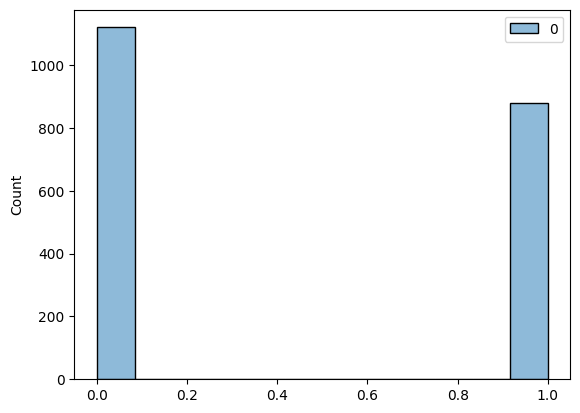

In [6]:
# Are the labels imbalanced ?
sns.histplot(data=raw_data.select(pl.col(target_col)))

<Axes: ylabel='Count'>

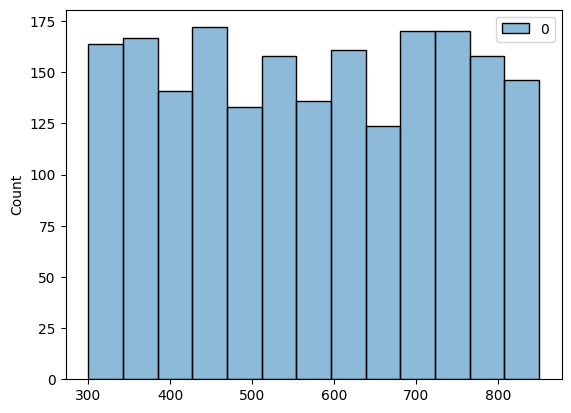

In [7]:
# Credit score distribution
sns.histplot(data=raw_data.select(pl.col("credit_score")))

In [8]:
# Missing value count
raw_data.null_count()

name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


In [9]:
# Feature importance using Correlation between feature and target variables
raw_data.select(
    pl.struct(pl.corr(pl.all(), pl.col(target_col))).alias(
        f"corr_with_{target_col}"
    )
).unpivot().unnest("value")

variable,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
str,f64,f64,f64,f64,f64,f64,f64,f64
"""corr_with_loan_approved""",NaN,NaN,0.238066,0.715788,-0.157859,0.104408,0.821415,1.0


In [10]:
# Check what the feature engineering would entail
raw_data.select(
    pl.corr(a=pl.col("loan_amount") / pl.col("income"), b="loan_approved")
)

loan_amount
f64
-0.249378


## Validation framework setup

In [ ]:
def split_label(dataset: pl.DataFrame, target_col: str):
    return dataset.drop(target_col), dataset[target_col]

full_x, full_y = split_label(raw_data, target_col=target_col)

In [ ]:
def split_dataset(dataset: pl.DataFrame, val_size=0.2, test_size=0.2, seed=1):
    train_size = 1 - test_size
    full_train_dataset, test_dataset = sklearn.model_selection.train_test_split(
        dataset, test_size=test_size, random_state=seed
    )
    train_dataset, val_dataset = sklearn.model_selection.train_test_split(
        full_train_dataset, test_size=val_size / train_size, random_state=seed
    )
    return train_dataset, val_dataset, test_dataset

x_raw_train, x_raw_val, x_raw_test = split_dataset(
    full_x, val_size=0.2, test_size=0.2, seed=1
)
y_raw_train, y_raw_val, y_raw_test = split_dataset(
    full_y, val_size=0.2, test_size=0.2, seed=1
)

In [13]:
def clean_dataset(X: pl.DataFrame, y: pl.DataFrame, num_cols: list[str]):
    return X.select(num_cols), y.cast(int).to_numpy()

x_train, y_train = clean_dataset(x_raw_train, y_raw_train, num_cols)
x_val, y_val = clean_dataset(x_raw_val, y_raw_val, num_cols)
x_test, y_test = clean_dataset(x_raw_test, y_raw_test, num_cols)

## Model Evaluation

* Fit model on full train set, evaluate on validation set
* Cross Validation

In [14]:
from sklearn.linear_model import LogisticRegression

model_logistic_regression = LogisticRegression(
    solver="liblinear", C=1.0, max_iter=1000, random_state=42
)
model_logistic_regression.fit(X=x_train, y=y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
)

def evaluate_model(model, x, y):
    y_pred = model_logistic_regression.predict(x)
    train_classification_report = classification_report(y, y_pred)
    print(f"Accuracy score: {accuracy_score(y, y_pred):.2f}")
    print(f"ROC AUC score: {roc_auc_score(y, y_pred):.2f}")
    print(f"Precision score: {precision_score(y, y_pred):.2f}")
    print(f"Recall score: {recall_score(y, y_pred):.2f}")
    print(train_classification_report)
    return train_classification_report

evaluate_model(model_logistic_regression, x_train, y_train)

Accuracy score: 0.83
ROC AUC score: 0.84
Precision score: 0.79
Recall score: 0.84
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       674
           1       0.79      0.84      0.82       526

    accuracy                           0.83      1200
   macro avg       0.83      0.84      0.83      1200
weighted avg       0.84      0.83      0.84      1200



'              precision    recall  f1-score   support\n\n           0       0.87      0.83      0.85       674\n           1       0.79      0.84      0.82       526\n\n    accuracy                           0.83      1200\n   macro avg       0.83      0.84      0.83      1200\nweighted avg       0.84      0.83      0.84      1200\n'

In [16]:
evaluate_model(model_logistic_regression, x_val, y_val)

Accuracy score: 0.85
ROC AUC score: 0.85
Precision score: 0.83
Recall score: 0.84
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       222
           1       0.83      0.84      0.84       178

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



'              precision    recall  f1-score   support\n\n           0       0.87      0.86      0.87       222\n           1       0.83      0.84      0.84       178\n\n    accuracy                           0.85       400\n   macro avg       0.85      0.85      0.85       400\nweighted avg       0.85      0.85      0.85       400\n'

In [17]:
from sklearn.model_selection import KFold
import numpy as np

full_train_X = np.concat([x_train.to_numpy(), x_val.to_numpy()])
full_train_y = np.concat([y_train, y_val])

def roc_scores_eval(full_train_X, full_train_y, C=1.0):
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    roc_scoreskf = []
    for i, (train_index, test_index) in enumerate(
        kf.split(full_train_X, full_train_y)
    ):
        x_train_kf, y_train_kf = (
            full_train_X[train_index],
            full_train_y[train_index],
        )
        x_val_kf, y_val_kf = full_train_X[test_index], full_train_y[test_index]
        model_kf = LogisticRegression(solver="liblinear", C=C, max_iter=1000)
        model_kf.fit(x_train_kf, y_train_kf)
        y_val_proba_pred_kf = model_kf.predict_proba(x_val_kf)[:, 1]
        roc_scoreskf.append(roc_auc_score(y_val_kf, y_val_proba_pred_kf))
        del model_kf
    return np.std(roc_scoreskf), round(np.mean(roc_scoreskf), 3)

roc_scores_eval(full_train_X, full_train_y)

(np.float64(0.010645861666719752), np.float64(0.912))

## Hyperparamater tuning

In [18]:
from sklearn.model_selection import GridSearchCV

parameters = {"C": [0.01, 1, 10], "max_iter": [1000], "solver": ["liblinear"]}
model_logistic_regression_gs = LogisticRegression()
clf = GridSearchCV(model_logistic_regression_gs, parameters)
clf.fit(full_train_X, full_train_y)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 1, ...], 'max_iter': [1000], 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [19]:
evaluate_model(clf, x_train, y_train)

Accuracy score: 0.83
ROC AUC score: 0.84
Precision score: 0.79
Recall score: 0.84
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       674
           1       0.79      0.84      0.82       526

    accuracy                           0.83      1200
   macro avg       0.83      0.84      0.83      1200
weighted avg       0.84      0.83      0.84      1200



'              precision    recall  f1-score   support\n\n           0       0.87      0.83      0.85       674\n           1       0.79      0.84      0.82       526\n\n    accuracy                           0.83      1200\n   macro avg       0.83      0.84      0.83      1200\nweighted avg       0.84      0.83      0.84      1200\n'

In [20]:
evaluate_model(clf, x_val, y_val)

Accuracy score: 0.85
ROC AUC score: 0.85
Precision score: 0.83
Recall score: 0.84
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       222
           1       0.83      0.84      0.84       178

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



'              precision    recall  f1-score   support\n\n           0       0.87      0.86      0.87       222\n           1       0.83      0.84      0.84       178\n\n    accuracy                           0.85       400\n   macro avg       0.85      0.85      0.85       400\nweighted avg       0.85      0.85      0.85       400\n'

In [21]:
clf

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 1, ...], 'max_iter': [1000], 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


## Saving model

In [ ]:
import pickle

model_folder = "../models"
model_name = "model_logistic_regression_C=1.0.bin"
with open(f"{model_folder}/{model_name}", "wb") as f_out:
    pickle.dump(clf, f_out)